In [1]:
%matplotlib inline
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import brainmass
import brainstate
import braintools
import brainunit as u
from brainstate.nn import Param
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Building a Data-Driven Workflow

This is the **extension playbook** for data-driven modeling in `brainmass`:
the stable contract you build a custom, *fittable* model against. Every piece
below is a public API the rest of the ecosystem -- and future tooling like the
deferred `Trainer` (see the final section) -- composes with.

We will go end to end:

1. **Expose trainable parameters** on a custom model with `Param(value, fit=True)`.
2. **Write a loss** as a small `objectives`-style `callable(prediction, target)`.
3. **Fit it** two ways: with the high-level `brainmass.Fitter`, and with a
   hand-written training loop over `braintools.optim` + `brainstate.transform.grad`.
4. **Batch the search** with `vmap`.

The data-driven layer is the center of gravity of `brainmass` (see
{doc}`/data_driven/index`). Read {doc}`creating_models` first for the model
contract itself; this guide is about making a model *learnable*.

## 1. A model with trainable parameters

A trainable parameter is just a `brainstate.nn.Param` with `fit=True`. That wraps
the value in a `ParamState` (a leaf the optimizers see); a plain float or
`Param.init(float)` stays a non-trainable `Const`. The model is otherwise an
ordinary `brainstate.nn.Dynamics` (see {doc}`creating_models`).

Two rules make a parameter *gradient-friendly* (learned the hard way across the
fitting tutorials):

- **Make the trainable dimensionless.** A `mV`-valued `Param` crashes the
  best-parameter snapshot inside `Fitter` (`jnp.asarray` refuses a unit-carrying
  value). Keep the knob a plain scalar; let units live on the *states*.
- **Fit a scalar summary, not a raw oscillatory trace.** Point-by-point time-series
  RMSE of a limit cycle is phase-degenerate and the gradient collapses. A steady
  state, an amplitude, an FC value, or a spectral peak is well-conditioned.

Here is a one-population leaky-rate model whose input gain `g` is trainable:

In [2]:
class GainPopulation(brainstate.nn.Dynamics):
    """Leaky firing-rate population with a trainable input gain ``g``.

    dr/dt = (-r + g * tanh(input)) / tau
    """

    def __init__(self, in_size, g=1.0, tau=10. * u.ms):
        super().__init__(in_size)
        self.tau = tau
        # fit=True -> a trainable ParamState; a dimensionless scalar knob.
        self.g = Param(g, fit=True)

    def init_state(self, batch_size=None):
        self.r = brainstate.HiddenState(
            braintools.init.param(braintools.init.Constant(0.0),
                                  self.varshape, batch_size)
        )

    def update(self, inp=0.0):
        r = self.r.value
        dr = (-r + self.g.value() * jnp.tanh(inp)) / self.tau
        self.r.value = r + dr * brainstate.environ.get_dt()
        return self.r.value


model = GainPopulation(1, g=0.5)
brainstate.nn.init_all_states(model)
# The trainable leaves the optimizers will see:
list(model.states(brainstate.ParamState).keys())

[('g', 'val')]

`states(ParamState)` returns the trainable leaves keyed by **tuple** paths
(`('g', 'val')`). Keep this in mind: a raw `brainstate.transform.grad` returns
gradients keyed by exactly these tuples, whereas `FitResult.best_params` uses the
**dotted** form (`'g'`, or `'node.g'` for a nested model). Same parameter, two
key conventions.

## 2. A loss as a composable objective

An objective is a *builder* that returns a small `callable(prediction, target) ->
scalar`, jit/grad/vmap-safe and unit-aware. This is exactly the shape of the
built-ins in `brainmass.objectives`, so a custom loss drops into the same slots.
The convention: strip units with `brainunit.get_magnitude` only where the metric
is scale-invariant; keep them on a difference you want unit-checked. See
{doc}`creating_an_objective` for the full contract.

Here the target behaviour is a *steady-state mean rate*, a clean scalar summary:

In [3]:
def steadystate_loss(n_tail=50):
    """Squared error between the settled mean rate and a scalar target."""
    def loss(prediction, target):
        amp = jnp.mean(u.get_magnitude(prediction[-n_tail:]))
        return (amp - target) ** 2
    return loss


def predict(m):
    """Run the model and return its rate trajectory (the prediction)."""
    sim = brainmass.Simulator(m, dt=0.1 * u.ms)
    res = sim.run(60. * u.ms, inputs=lambda i, t: 1.0, monitors=['r'])
    return res['r']


# Ground truth: the trajectory of the model at g* = 2.0.
truth = GainPopulation(1, g=2.0)
target_amp = jnp.mean(u.get_magnitude(predict(truth)[-50:]))
float(target_amp)

1.5184532403945923

## 3a. Fit with `brainmass.Fitter`

`Fitter` is the one-call path. You hand it the model, an optimizer, and either a
`loss_fn(model) -> (scalar, aux)` *or* an `objective` + `predict` pair (as here).
It registers the trainable weights, builds the jitted gradient step, tracks the
best-seen point, and returns a `FitResult`. The `'grad'` backend reproduces the
canonical hand-rolled loop exactly -- which we verify next.

In [4]:
model = GainPopulation(1, g=0.5)
fitter = brainmass.Fitter(
    model,
    braintools.optim.Adam(lr=0.1),
    objective=steadystate_loss(),
    predict=predict,
)
result = fitter.fit(target=target_amp, n_steps=60)
print(result)
print('recovered g =', {k: round(float(v), 4) for k, v in result.best_params.items()})
print('best loss   =', float(result.best_loss))

FitResult(backend='grad', best_loss=1.66887e-05, n_steps=60, params=[g])
recovered g = {'g': 1.9878}
best loss   = 1.6688674804754555e-05


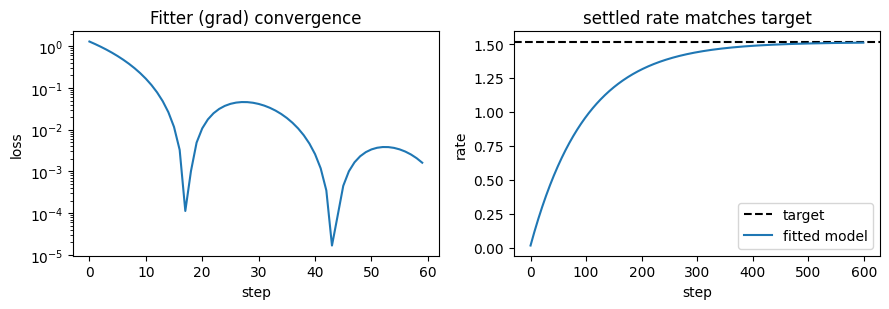

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(result.history)
ax[0].set(xlabel='step', ylabel='loss', title='Fitter (grad) convergence')
ax[0].set_yscale('log')
ax[1].axhline(float(target_amp), ls='--', c='k', label='target')
ax[1].plot(u.get_magnitude(predict(model)), label='fitted model')
ax[1].set(xlabel='step', ylabel='rate', title='settled rate matches target')
ax[1].legend()
fig.tight_layout()

## 3b. The same fit, hand-written

`Fitter`'s `'grad'` backend *is* this loop. Writing it out is worth doing once,
because the moment you need something `Fitter` does not expose -- minibatches, an
epoch loop, a held-out metric -- you drop down to exactly this and add your own
control flow. The five lines that matter:

1. `weights = model.states(brainstate.ParamState)` -- the trainable leaves.
2. `optimizer.register_trainable_weights(weights)`.
3. a loss closure run inside `model.param_precompute()` (applies transforms /
   precompute), adding `model.reg_loss()`.
4. `brainstate.transform.grad(loss, weights, return_value=True)`.
5. `optimizer.step(grads)` -- all wrapped in `brainstate.transform.jit`.

In [6]:
model2 = GainPopulation(1, g=0.5)
weights = model2.states(brainstate.ParamState)
optimizer = braintools.optim.Adam(lr=0.1)
optimizer.register_trainable_weights(weights)

def loss_closure():
    with model2.param_precompute():
        loss = steadystate_loss()(predict(model2), target_amp)
        return loss + model2.reg_loss()

@brainstate.transform.jit
def train_step():
    grad_fn = brainstate.transform.grad(loss_closure, weights, return_value=True)
    grads, loss = grad_fn()
    optimizer.step(grads)
    return loss

history = [float(train_step()) for _ in range(60)]
print('hand-rolled g =', round(float(model2.g.value()), 4))
print('final loss    =', history[-1])
# Same key gotcha: a standalone grad is keyed by the ParamState tuple, not 'g'.
grad_fn = brainstate.transform.grad(loss_closure, weights, return_value=True)
grads, _ = grad_fn()
print('raw grad keys =', list(grads.keys()))

hand-rolled g = 1.9546
final loss    = 0.0016139140352606773


raw grad keys = [('g', 'val')]


Both paths converge to the same `g ~ 2.0`. The hand-rolled loop is the template a
task-shaped trainer extends -- see the final section, *Where this is going*.

## 4. Batch the search with `vmap`

To evaluate the loss across many parameter values at once, `vmap` **over
parameters** -- build a fresh model inside the mapped function and map over the
scalar. This is the supported batching axis. (Batching *states* through
`init_all_states(batch_size=...)` is the right tool for an ensemble of one model,
but a delay-coupled network's prefetch does not vectorise that way -- vmap over
parameters instead.)

vmap grid minimum at g = 2.0


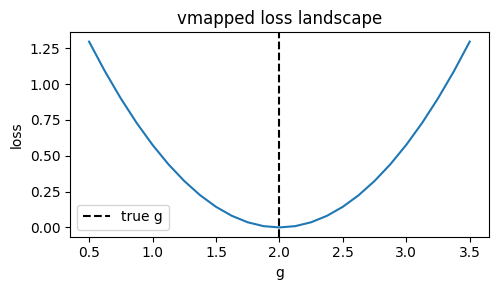

In [7]:
def loss_at(g_value):
    m = GainPopulation(1, g=g_value)
    return steadystate_loss()(predict(m), target_amp)

grid = jnp.linspace(0.5, 3.5, 25)
losses = jax.vmap(loss_at)(grid)        # all 25 evaluated in one compiled call
best = grid[jnp.argmin(losses)]
print('vmap grid minimum at g =', round(float(best), 3))

plt.figure(figsize=(5, 3))
plt.plot(grid, losses)
plt.axvline(2.0, ls='--', c='k', label='true g')
plt.xlabel('g'); plt.ylabel('loss'); plt.title('vmapped loss landscape')
plt.legend(); plt.tight_layout()

## Where this is going

Everything above is the stable, public contract:

| Piece | API |
| --- | --- |
| trainable parameter | `Param(value, fit=True)` |
| loss | `objectives`-style `callable(prediction, target)` |
| one-call fit | `brainmass.Fitter(...).fit(target=...)` |
| custom loop | `states(ParamState)` -> `register_trainable_weights` -> `grad` -> `step` |
| batched search | `jax.vmap` over parameters |

**`Fitter` fits one fixed target** -- a single `predict(model) -> prediction`
compared against one `target`. Task training (minibatched `(inputs, targets)`, an
epoch loop, a held-out metric) is *not* something `Fitter` exposes; you reach for
the hand-written loop in section 3b and add the batching yourself.

That gap is named and given a home -- but deliberately **not built yet** -- as the
deferred **`Trainer`** in the {doc}`/data_driven/roadmap`. A future goal will build
the `Trainer` (and model-discovery tooling) *against this exact contract*: it wraps
the section-3b loop plus batched state initialisation, and registers its datasets
through `brainmass.datasets`. Authoring a custom model, objective, and loop the way
this guide does is precisely what makes it slot in without restructuring.

## See Also

- {doc}`creating_models` -- the model contract this builds on.
- {doc}`creating_an_objective` -- the objective contract in depth.
- {doc}`/data_driven/index` -- the data-driven pillar and its roadmap.
- {doc}`/tutorials/06_fitting_with_gradients` -- a worked end-to-end fit.